In [1]:
!pip install BioPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.5 MB/s eta 0:00:00


In [3]:
# add the csv file of t_dataset_combined.csv
#add the iupred3 , iupred3_lib
# add the data folder


In [4]:

import sys
!conda install --yes --prefix {sys.prefix} -c bioconda ncbi-blast
!apt-get update
!apt-get install -y ncbi-blast+

/bin/bash: line 1: conda: command not found
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [108 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,314 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,557 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,199 kB]
Hit:13 https://ppa.launchpadcon

In [ ]:
# import zipfile
# with zipfile.ZipFile('/content/data.zip', 'r') as z:
#       z.extractall('/content/')

In [7]:
import sys
sys.path.insert(0, "/content")

import iupred3_lib

In [8]:
import math
import subprocess
import tempfile
import os

import numpy as np
import pandas as pd
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils.IsoelectricPoint import IsoelectricPoint as IP

AA_array = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
            'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

# Kyte-Doolittle hydrophobicity scale
kd = {"A": 1.8, "R": -4.5, "N": -3.5, "D": -3.5, "C": 2.5, "Q": -3.5,
      "E": -3.5, "G": -0.4, "H": -3.2, "I": 4.5, "L": 3.8, "K": -3.9,
      "M": 1.9, "F": 2.8, "P": -1.6, "S": -0.8, "T": -0.7, "W": -0.9,
      "Y": -1.3, "V": 4.2}

# The 5 residue-class groupings used throughout the paper
Hydrophobic_AAs = ['A', 'I', 'L', 'M', 'F', 'V']
Polar_AAs = ['S', 'Q', 'N', 'G', 'C', 'T', 'P']
Cation_AAs = ['K', 'R', 'H']
Anion_AAs = ['D', 'E']
Arom_AAs = ['W', 'Y', 'F']


def hydrophobicity(seq):
    """Sum of Kyte-Doolittle values over the sequence (Eq. used in paper's Fig. 2B)."""
    sequence = ProteinAnalysis(seq)
    counts = sequence.count_amino_acids()
    return sum(counts[aa] * kd[aa] for aa in AA_array)


def shannon_entropy(seq):
    """H(X) = -sum(p_i * log2(p_i)) over the 20 natural amino acids (paper Eq. 1)."""
    sequence = ProteinAnalysis(seq)
    # NOTE: in current BioPython, amino_acids_percent is on a 0-100 scale,
    # not 0-1 (unlike the older API the original paper code assumed) --
    # must divide by 100 to get a proper probability for Shannon entropy.
    percents = sequence.amino_acids_percent
    entropy = 0
    for aa in AA_array:
        p = percents[aa] / 100
        if p > 0:
            entropy -= p * math.log2(p)
    return entropy


def extract_lcr(seq):
    """
    Low-Complexity Region extraction using the SEG algorithm, invoked
    here via NCBI BLAST+'s `segmasker` command-line tool (this is what
    the original SEG-algorithm reference in the paper corresponds to).
    Returns (number_of_LCR_residues, concatenated_LCR_sequence).
    """
    with tempfile.NamedTemporaryFile(mode='w', suffix='.fasta', delete=False) as f:
        f.write('>seq\n' + seq)
        fasta_path = f.name

    out = subprocess.run(['segmasker', '-in', fasta_path],
                          capture_output=True, text=True)
    tokens = out.stdout.split()[1:]  # drop the leading ">seq"

    starts, ends = [], []
    for i in range(len(tokens) // 3):
        starts.append(int(tokens[3 * i]))
        ends.append(int(tokens[3 * i + 2]))

    lcr_positions = sorted({p for s, e in zip(starts, ends) for p in range(s, e + 1)}) # segmasker positions are 1-indexed (not 0-indexed)
    lcr_sequence = ''.join(seq[p-1] for p in lcr_positions) # adjust to 0-indexed for python string access
    return len(lcr_positions), lcr_sequence


def extract_idr(seq):
    """
    Calculate IDR residues using IUPred3 long disorder mode.

    Score > 0.5 is considered disordered.
    A stretch contributes only if it contains >=20
    consecutive disordered residues.
    """

    # IUPred3 medium smoothing requires >=19 residues.
    # For shorter sequences, use no smoothing.
    smoothing = "medium" if len(seq) >= 19 else "no"

    probs = iupred3_lib.iupred(
        seq,
        mode="long",
        smoothing=smoothing
    )[0]

    THRESHOLD = 0.5
    MIN_STRETCH = 20

    idr_residue_count = 0
    current = 0

    for p in probs:

        if p > THRESHOLD:
            current += 1
        else:
            if current >= MIN_STRETCH:
                idr_residue_count += current

            current = 0

    # Handle stretch reaching the end
    if current >= MIN_STRETCH:
        idr_residue_count += current

    return idr_residue_count


def get_aa_count(seq, aa):
    return ProteinAnalysis(seq).count_amino_acids()[aa]


def compute_features(df, seq_col='Sequence'):
    df = df.copy()
    df['Sequence_length'] = df[seq_col].str.len()

    print("  computing LCRs (segmasker)...")
    lcr_results = [extract_lcr(s) for s in df[seq_col]]
    df['LCR_length'] = [r[0] for r in lcr_results]
    df['LCR_sequence'] = [r[1] for r in lcr_results]
    df['LCR_frac'] = df['LCR_length'] / df['Sequence_length']

    print("  computing hydrophobicity / Shannon entropy / pI...")
    df['Hydrophobicity'] = [hydrophobicity(s) for s in df[seq_col]]
    df['Shannon_entropy'] = [shannon_entropy(s) for s in df[seq_col]]
    df['pI'] = [IP(s).pi() for s in df[seq_col]]

    print("  computing IDRs (IUPred2a)...")
    idr_results = []

    for i, seq in enumerate(df[seq_col]):
        idr_results.append(extract_idr(seq))

        if (i + 1) % 100 == 0:
            print(f"    IDR: {i + 1}/{len(df)}")

    df['IDR_residues'] = idr_results
    df['IDR_frac'] = df['IDR_residues'] / df['Sequence_length']

    print("  computing amino acid composition (full sequence)...")
    for aa in AA_array:
        df[f'AA_{aa}'] = [get_aa_count(s, aa) for s in df[seq_col]]

    df['HB'] = df[[f'AA_{a}' for a in Hydrophobic_AAs]].sum(axis=1)
    df['Polar'] = df[[f'AA_{a}' for a in Polar_AAs]].sum(axis=1)
    df['Arom'] = df[[f'AA_{a}' for a in Arom_AAs]].sum(axis=1)
    df['Cation'] = df[[f'AA_{a}' for a in Cation_AAs]].sum(axis=1)
    df['Anion'] = df[[f'AA_{a}' for a in Anion_AAs]].sum(axis=1)
    for name in ['HB', 'Polar', 'Arom', 'Cation', 'Anion']:
        df[f'{name}_frac'] = (df[name] / df['Sequence_length']).fillna(0)

    print("  computing amino acid composition (within LCRs only)...")
    for aa in AA_array:
        df[f'AA_LCR_{aa}'] = [get_aa_count(s, aa) if len(s) > 0 else 0 for s in df['LCR_sequence']]

    df['HB_LCR'] = df[[f'AA_LCR_{a}' for a in Hydrophobic_AAs]].sum(axis=1)
    df['Polar_LCR'] = df[[f'AA_LCR_{a}' for a in Polar_AAs]].sum(axis=1)
    df['Arom_LCR'] = df[[f'AA_LCR_{a}' for a in Arom_AAs]].sum(axis=1)
    df['Cation_LCR'] = df[[f'AA_LCR_{a}' for a in Cation_AAs]].sum(axis=1)
    df['Anion_LCR'] = df[[f'AA_LCR_{a}' for a in Anion_AAs]].sum(axis=1)
    for name in ['HB_LCR', 'Polar_LCR', 'Arom_LCR', 'Cation_LCR', 'Anion_LCR']:
        df[f'{name}_frac'] = (df[name] / df['LCR_length']).fillna(0)

    df = df.drop(columns=['LCR_sequence'])
    return df


if __name__ == '__main__':
    training_data = pd.read_csv('/content/training_dataset_combined.csv')
    print(f"Loaded {training_data.shape[0]} sequences to featurize")

    featurized = compute_features(training_data)

    featurized.to_csv('training_data_EF_features.csv', index=False)

    print()
    print(f"Done. Feature table shape: {featurized.shape}")
    print(featurized[['Sequence', 'Category', 'Sequence_length', 'Hydrophobicity',
                       'Shannon_entropy', 'LCR_frac', 'IDR_frac',
                       'Polar_frac', 'HB_frac', 'Arom_frac', 'Cation_frac',
                       'Anion_frac']].head())

Loaded 1783 sequences to featurize
  computing LCRs (segmasker)...
  computing hydrophobicity / Shannon entropy / pI...
  computing IDRs (IUPred2a)...
    IDR: 100/1783
    IDR: 200/1783
    IDR: 300/1783
    IDR: 400/1783
    IDR: 500/1783
    IDR: 600/1783
    IDR: 700/1783
    IDR: 800/1783
    IDR: 900/1783
    IDR: 1000/1783
    IDR: 1100/1783
    IDR: 1200/1783
    IDR: 1300/1783
    IDR: 1400/1783
    IDR: 1500/1783
    IDR: 1600/1783
    IDR: 1700/1783
  computing amino acid composition (full sequence)...
  computing amino acid composition (within LCRs only)...

Done. Feature table shape: (1783, 71)
                                            Sequence Category  \
0  AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKK...    LLPS+   
1  ASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDT...    LLPS+   
2  CLRKKRKPQAEKVDVIAGSSKMKGFSSSESESSSESSSSDSEDSET...    LLPS+   
3  DFDVYVLAKLLGFASEELQEEIEIIRDNVTDAFEACKPLLKKLMIE...    LLPS+   
4  EHHSGSQGPLLTTGDLGKEKTQKRVKEGNGTSNSTLSGPGLDSKPG...    LLPS

To resolve the `FileNotFoundError` for `segmasker`, we need to install NCBI BLAST+, which includes the `segmasker` utility. We will use `conda` via `mamba` to install `ncbi-blast`.

In [ ]:
# diagrams generations

Saved llps_plus_feature_histograms.png (n=135 LLPS+ proteins)


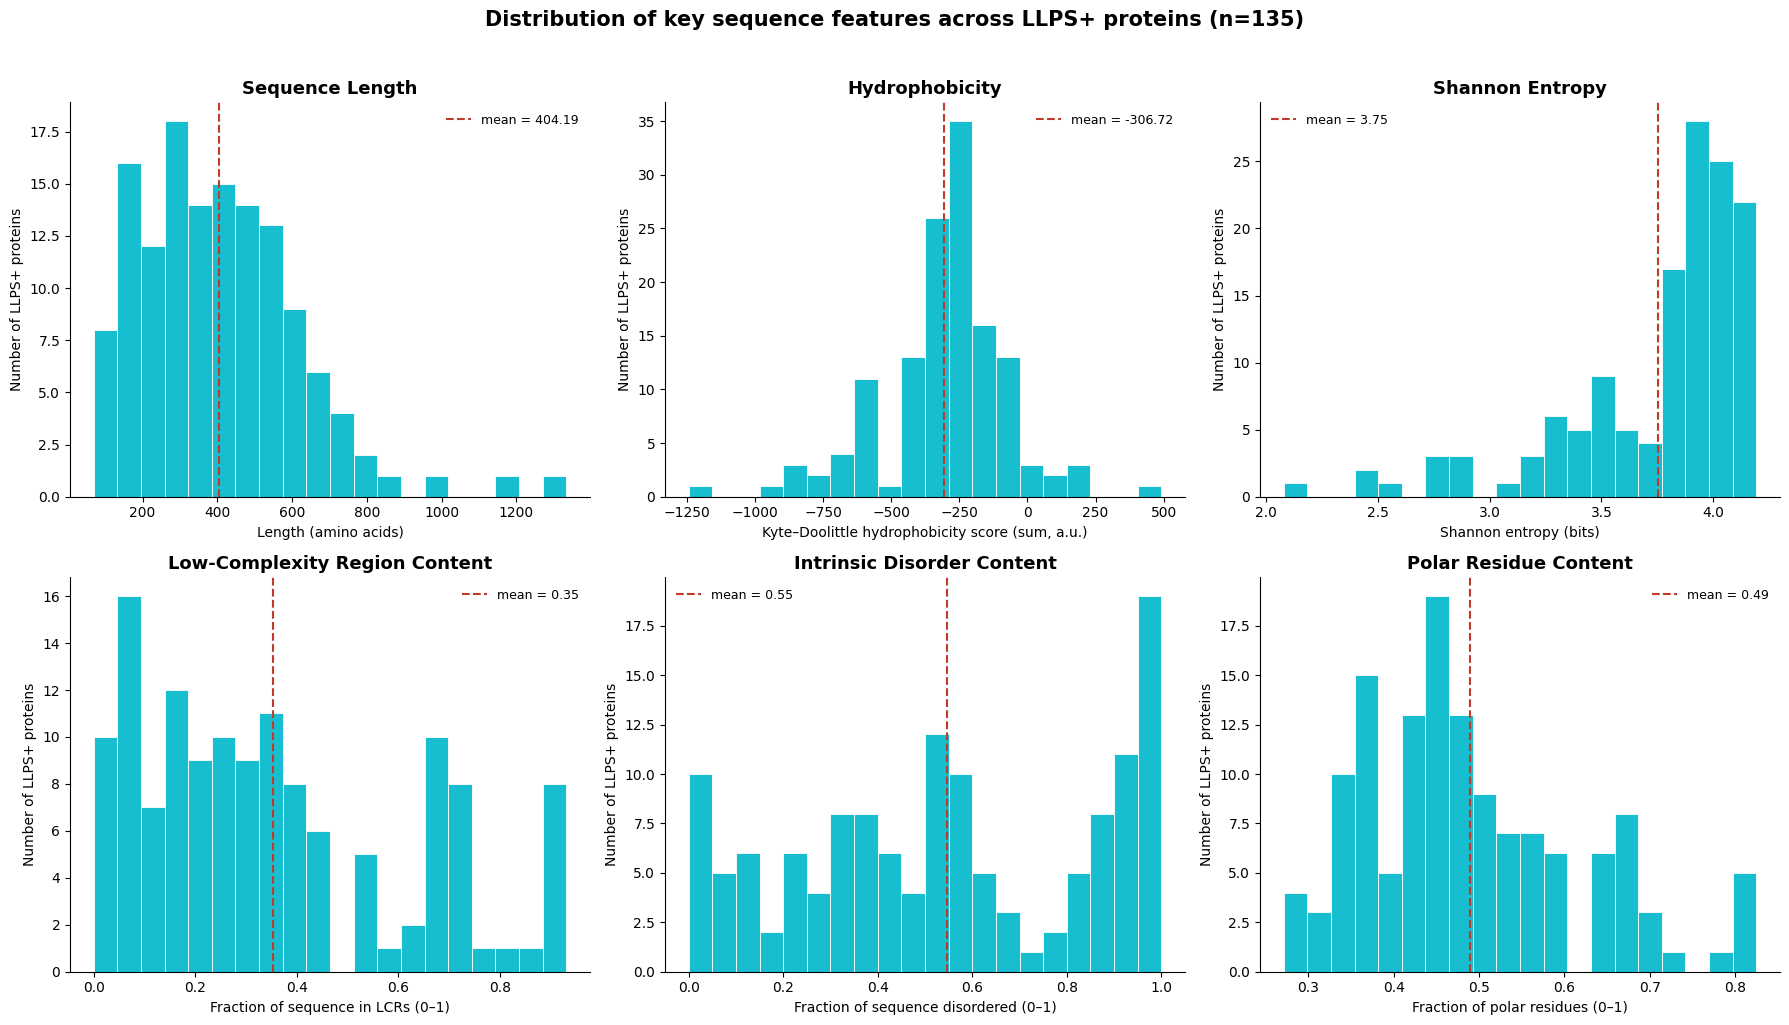

In [9]:
"""
STEP 4 (corrected): Histogram of LLPS+ proteins for 6 key features.

x-axis = feature value (with proper physical units)
y-axis = number of LLPS+ proteins (count)
"""
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/training_data_EF_features.csv')
llps_plus = df[df['Category'] == 'LLPS+']
n = len(llps_plus)

# (column, title, x-axis label WITH units, number of bins, mean-line color)
FEATURES = [
    ('Sequence_length', 'Sequence Length', 'Length (amino acids)', 20),
    ('Hydrophobicity', 'Hydrophobicity', 'Kyte–Doolittle hydrophobicity score (sum, a.u.)', 20),
    ('Shannon_entropy', 'Shannon Entropy', 'Shannon entropy (bits)', 20),
    ('LCR_frac', 'Low-Complexity Region Content', 'Fraction of sequence in LCRs (0–1)', 20),
    ('IDR_frac', 'Intrinsic Disorder Content', 'Fraction of sequence disordered (0–1)', 20),
    ('Polar_frac', 'Polar Residue Content', 'Fraction of polar residues (0–1)', 20),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title, xlabel, bins) in zip(axes, FEATURES):
    vals = llps_plus[col]
    ax.hist(vals, bins=bins, color='#17becf', edgecolor='white', linewidth=0.6)
    mean_val = vals.mean()
    ax.axvline(mean_val, color='#c0392b', linestyle='--', linewidth=1.5,
               label=f'mean = {mean_val:.2f}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Number of LLPS+ proteins', fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Distribution of key sequence features across LLPS+ proteins (n={n})',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('llps_plus_feature_histograms.png', dpi=200, bbox_inches='tight')
print(f"Saved llps_plus_feature_histograms.png (n={n} LLPS+ proteins)")